# MMHS150K — VRAM Feasibility Test
Tests all model+precision variants across dual T4 (2×16GB = 32GB total).
Each variant: load → one inference → measure VRAM → free → next.

**Dataset**: `victorcallejasf/multimodal-hate-speech` (base Kaggle dataset)

In [1]:
!pip install -q 'transformers>=4.57.0' bitsandbytes accelerate 'qwen_vl_utils>=0.0.14' Pillow
print('done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 55.8 MB/s eta 0:00:00:00:0100:01
done


Test image : 1061004551396999171.jpg
Image size : (666, 500)


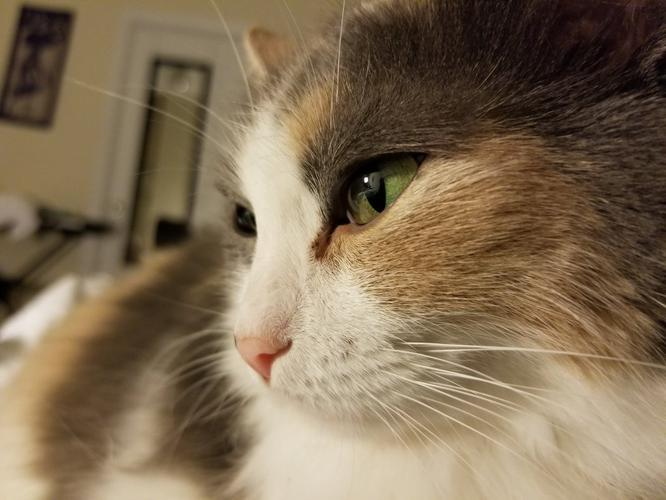

  GPU 0: Tesla T4 — 15.6 GB total
  GPU 1: Tesla T4 — 15.6 GB total
  Combined VRAM: 31.3 GB
Setup complete.


In [3]:
# ── Setup ─────────────────────────────────────────────────────────────────
import gc, json, time
import torch
from pathlib import Path
from PIL import Image

# Base Kaggle dataset path
INPUT_DIR = Path('/kaggle/input/datasets/victorcallejasf/multimodal-hate-speech')
WORK_DIR  = Path('/kaggle/working')
IMG_DIR   = INPUT_DIR / 'img_resized'

# Pick one real test image from the dataset
TEST_IMAGE = next(IMG_DIR.glob('*.jpg'))
TEST_PROMPT = 'Describe this image briefly in one sentence.'
print(f'Test image : {TEST_IMAGE.name}')
print(f'Image size : {Image.open(TEST_IMAGE).size}')
img = Image.open(TEST_IMAGE)
display(img)

# GPU info
n_gpus = torch.cuda.device_count()
for i in range(n_gpus):
    total = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)} — {total:.1f} GB total')
combined = sum(torch.cuda.get_device_properties(i).total_memory for i in range(n_gpus)) / 1e9
print(f'  Combined VRAM: {combined:.1f} GB')

RESULTS = []

def vram_used():
    used = [torch.cuda.memory_allocated(i)/1e9 for i in range(torch.cuda.device_count())]
    return used, sum(used)

def free_all():
    gc.collect()
    for i in range(torch.cuda.device_count()):
        torch.cuda.empty_cache()
    torch.cuda.synchronize()

def report(name, status, used_per_gpu, total_used, elapsed, caption=''):
    per_gpu_str = ' + '.join(f'{v:.1f}' for v in used_per_gpu) + f' = {total_used:.1f} GB'
    print(f'  [{status:>3}] {name:<38} VRAM: {per_gpu_str}  time: {elapsed:.1f}s')
    if caption:
        print(f'         caption: {caption[:110]}')
    RESULTS.append({
        'model':         name,
        'status':        status,
        'vram_total_gb': round(total_used, 2),
        'vram_per_gpu':  [round(v, 2) for v in used_per_gpu],
        'inference_s':   round(elapsed, 2),
    })

print('Setup complete.')



In [3]:
# ── Shared Qwen3‑VL inference helper ──────────────────────────────────────
def qwen3_infer(model, processor):
    from qwen_vl_utils import process_vision_info
    img = Image.open(TEST_IMAGE).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": img},
                {"type": "text", "text": TEST_PROMPT},
            ],
        }
    ]

    # Chat template for Qwen3‑VL
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    # Let qwen_vl_utils handle resizing, pass correct patch size from processor
    image_inputs, video_inputs = process_vision_info(
        messages,
        image_patch_size=processor.image_processor.patch_size,
    )

    # IMPORTANT: do_resize=False because process_vision_info already resized
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        do_resize=False,
        return_tensors="pt",
    )

    # Send everything to the model's device (handles device_map='auto')
    inputs = inputs.to(model.device)

    t0 = time.time()
    with torch.no_grad():
        generated_ids = model.generate(**inputs, max_new_tokens=50)
    elapsed = time.time() - t0

    # Strip the prompt tokens before decoding
    prompt_len = inputs.input_ids.shape[1]
    generated_ids_trimmed = generated_ids[:, prompt_len:]

    caption = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False,
    )[0].strip()

    return elapsed, caption

print("Qwen3 helper ready.")

Qwen3 helper ready.


In [4]:
# ── Test 1: Qwen3‑VL‑4B FP16 single GPU (~9GB) ─────────────────────────
NAME = "Qwen3-VL-4B FP16 (cuda:0)"
print(f"\n[TEST] {NAME}")
model = processor = None
try:
    from transformers import AutoModelForImageTextToText, AutoProcessor

    model = AutoModelForImageTextToText.from_pretrained(
        "Qwen/Qwen3-VL-4B-Instruct",
        torch_dtype=torch.float16,
        device_map="cuda:0",  # single GPU
    ).eval()

    processor = AutoProcessor.from_pretrained(
        "Qwen/Qwen3-VL-4B-Instruct"
    )

    used, total = vram_used()
    elapsed, caption = qwen3_infer(model, processor)
    report(NAME, "OK", used, total, elapsed, caption)
except torch.cuda.OutOfMemoryError:
    used, total = vram_used()
    report(NAME, "OOM", used, total, 0)
finally:
    del model, processor
    free_all()


[TEST] Qwen3-VL-4B FP16 (cuda:0)


config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

  [ OK] Qwen3-VL-4B FP16 (cuda:0)              VRAM: 8.9 + 0.0 = 8.9 GB  time: 4.8s
         caption: A close-up portrait of a calico cat with striking green eyes, gazing thoughtfully to the side.


In [5]:
# ── Test 2: Qwen3‑VL‑4B BF16 single GPU (~9GB) ─────────────────────────
NAME = "Qwen3-VL-4B BF16 (cuda:0)"
print(f"\n[TEST] {NAME}")
model = processor = None
try:
    from transformers import AutoModelForImageTextToText, AutoProcessor

    model = AutoModelForImageTextToText.from_pretrained(
        "Qwen/Qwen3-VL-4B-Instruct",
        torch_dtype=torch.bfloat16,
        device_map="cuda:0",
    ).eval()

    processor = AutoProcessor.from_pretrained(
        "Qwen/Qwen3-VL-4B-Instruct"
    )

    used, total = vram_used()
    elapsed, caption = qwen3_infer(model, processor)
    report(NAME, "OK", used, total, elapsed, caption)
except torch.cuda.OutOfMemoryError:
    used, total = vram_used()
    report(NAME, "OOM", used, total, 0)
finally:
    del model, processor
    free_all()


[TEST] Qwen3-VL-4B BF16 (cuda:0)


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

  [ OK] Qwen3-VL-4B BF16 (cuda:0)              VRAM: 8.9 + 0.0 = 8.9 GB  time: 14.4s
         caption: A close-up portrait of a calico cat with striking green eyes, looking off to the side with a calm, contemplati


In [6]:
# ── Test 3: Qwen3‑VL‑8B FP16 both GPUs (~17GB split) ───────────────────
NAME = "Qwen3-VL-8B FP16 (device_map=auto)"
print(f"\n[TEST] {NAME}")
model = processor = None
try:
    from transformers import AutoModelForImageTextToText, AutoProcessor

    model = AutoModelForImageTextToText.from_pretrained(
        "Qwen/Qwen3-VL-8B-Instruct",
        torch_dtype=torch.float16,
        device_map="auto",  # let HF split across both GPUs
    ).eval()

    processor = AutoProcessor.from_pretrained(
        "Qwen/Qwen3-VL-8B-Instruct"
    )

    used, total = vram_used()
    elapsed, caption = qwen3_infer(model, processor)
    report(NAME, "OK", used, total, elapsed, caption)
except torch.cuda.OutOfMemoryError:
    used, total = vram_used()
    report(NAME, "OOM", used, total, 0)
finally:
    del model, processor
    free_all()


[TEST] Qwen3-VL-8B FP16 (device_map=auto)


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

  [ OK] Qwen3-VL-8B FP16 (device_map=auto)     VRAM: 7.8 + 9.7 = 17.5 GB  time: 2.4s
         caption: A close-up of a fluffy calico cat with striking green eyes looking thoughtfully to the side.


In [7]:
# ── Test 4: Qwen3‑VL‑8B BF16 both GPUs (~17GB split) ───────────────────
NAME = "Qwen3-VL-8B BF16 (device_map=auto)"
print(f"\n[TEST] {NAME}")
model = processor = None
try:
    from transformers import AutoModelForImageTextToText, AutoProcessor

    model = AutoModelForImageTextToText.from_pretrained(
        "Qwen/Qwen3-VL-8B-Instruct",
        torch_dtype=torch.bfloat16,
        device_map="auto",
    ).eval()

    processor = AutoProcessor.from_pretrained(
        "Qwen/Qwen3-VL-8B-Instruct"
    )

    used, total = vram_used()
    elapsed, caption = qwen3_infer(model, processor)
    report(NAME, "OK", used, total, elapsed, caption)
except torch.cuda.OutOfMemoryError:
    used, total = vram_used()
    report(NAME, "OOM", used, total, 0)
finally:
    del model, processor
    free_all()


[TEST] Qwen3-VL-8B BF16 (device_map=auto)


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

  [ OK] Qwen3-VL-8B BF16 (device_map=auto)     VRAM: 7.8 + 9.7 = 17.6 GB  time: 16.2s
         caption: A close-up of a calico cat with striking green eyes looking thoughtfully to the side.


In [8]:
# ── Test 5: Qwen3-VL-8B INT8 single GPU (~9GB) ─────────────────────────
NAME = 'Qwen3-VL-8B INT8 (device_map=auto)'
print(f'\n[TEST] {NAME}')
model = processor = None
try:
    from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

    bnb8 = BitsAndBytesConfig(load_in_8bit=True)

    # FIX 1: use AutoModelForImageTextToText instead of Qwen3VLForConditionalGeneration
    # FIX 2: no torch_dtype with BnB quantization — BnB manages its own dtype internally
    model = AutoModelForImageTextToText.from_pretrained(
        'Qwen/Qwen3-VL-8B-Instruct',
        quantization_config=bnb8,
        device_map='auto',
    ).eval()

    # FIX 3: max_pixels belongs in the processor, not as a kwarg here — already correct,
    #         but pass it via min_pixels/max_pixels to the processor properly
    processor = AutoProcessor.from_pretrained(
        'Qwen/Qwen3-VL-8B-Instruct',
        min_pixels=256 * 256,
        max_pixels=448 * 448,
    )

    used, total = vram_used()
    elapsed, caption = qwen3_infer(model, processor)
    report(NAME, 'OK', used, total, elapsed, caption)

except torch.cuda.OutOfMemoryError:
    used, total = vram_used()
    report(NAME, 'OOM', used, total, 0)
finally:
    del model, processor; free_all()



[TEST] Qwen3-VL-8B INT8 (device_map=auto)


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


  [ OK] Qwen3-VL-8B INT8 (device_map=auto)     VRAM: 3.4 + 6.7 = 10.1 GB  time: 17.8s
         caption: A close-up of a fluffy calico cat with striking green eyes looking off to the side.


In [9]:
# ── Test 6: Qwen3-VL-8B INT4 NF4 single GPU (~5-6GB) ───────────────────
NAME = 'Qwen3-VL-8B INT4-NF4 (device_map=auto)'
print(f'\n[TEST] {NAME}')
model = processor = None
try:
    from transformers import AutoModelForImageTextToText, AutoProcessor, BitsAndBytesConfig

    bnb4 = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type='nf4',
    )

    # FIX 1: correct model class
    model = AutoModelForImageTextToText.from_pretrained(
        'Qwen/Qwen3-VL-8B-Instruct',
        quantization_config=bnb4,
        device_map='auto',
    ).eval()

    processor = AutoProcessor.from_pretrained(
        'Qwen/Qwen3-VL-8B-Instruct',
        min_pixels=256 * 256,
        max_pixels=448 * 448,
    )

    used, total = vram_used()
    elapsed, caption = qwen3_infer(model, processor)
    report(NAME, 'OK', used, total, elapsed, caption)

except torch.cuda.OutOfMemoryError:
    used, total = vram_used()
    report(NAME, 'OOM', used, total, 0)
finally:
    del model, processor; free_all()



[TEST] Qwen3-VL-8B INT4-NF4 (device_map=auto)


Loading weights:   0%|          | 0/750 [00:00<?, ?it/s]

  [ OK] Qwen3-VL-8B INT4-NF4 (device_map=auto) VRAM: 1.7 + 4.7 = 6.4 GB  time: 15.7s
         caption: A close-up of a calico cat with striking green eyes gazing thoughtfully to the side.
